<a href="https://www.kaggle.com/code/aamir28/1-260-micro-saas-launches?scriptVersionId=330693205" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#fff7f2;border-radius:16px;font-family:'Segoe UI',sans-serif;overflow:hidden;border:1px solid #ffd5b8;">

  <div style="background:linear-gradient(135deg,#ff6154 0%,#ff8a5c 100%);padding:30px 40px;">
    <div style="display:flex;justify-content:space-between;align-items:flex-start;">
      <div>
        <div style="font-size:0.65rem;letter-spacing:4px;color:#fff0e8;font-weight:700;margin-bottom:8px;">🚀 PRODUCT HUNT LAUNCH SNAPSHOT</div>
        <h1 style="margin:0;font-size:2rem;font-weight:900;color:#fff;">1,260 Micro-SaaS Launches</h1>
        <p style="margin:8px 0 0;color:#fff0e8;font-size:0.85rem;max-width:560px;line-height:1.7;">A 3-day window (May 29–31, 2026) of indie product launches — what founders are building, which niches dominate, and how deeply AI has been woven into the new-product pipeline.</p>
      </div>
      <div style="background:rgba(255,255,255,0.15);border-radius:10px;padding:14px 18px;text-align:center;min-width:90px;">
        <div style="font-size:2.2rem;">📦</div>
        <div style="font-size:0.62rem;color:#fff;margin-top:4px;">1,260 LAUNCHES</div>
      </div>
    </div>
  </div>

  <!-- Honest data-quality callout — this dataset has NO financial data despite the columns -->
  <div style="padding:18px 40px;background:#fff0e6;border-bottom:1px solid #ffd5b8;">
    <div style="display:flex;gap:10px;align-items:flex-start;">
      <span style="font-size:1.1rem;">⚠️</span>
      <p style="margin:0;color:#9a3412;font-size:0.82rem;line-height:1.7;"><strong>Data quality note:</strong> Despite columns for MRR, ARR, asking price, growth rate, and
      team size, <strong>100% of these fields are empty</strong> for all 1,260 products — this dataset is purely a
      Product Hunt launch catalog, not a revenue/valuation dataset, despite its filename. We pivot the analysis
      accordingly: instead of financial benchmarking, we study launch patterns, niche distribution, and the
      depth of AI adoption in 2026's indie software scene — which the data genuinely supports.</p>
    </div>
  </div>

  <!-- Metrics strip -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#fff7f2;">
    <div style="padding:16px 18px;border-right:1px solid #ffd5b8;text-align:center;">
      <div style="font-size:0.6rem;color:#ff6154;letter-spacing:1px;margin-bottom:5px;">AI-INTEGRATED</div>
      <div style="font-size:1.4rem;font-weight:800;color:#9a3412;">40.8%</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #ffd5b8;text-align:center;">
      <div style="font-size:0.6rem;color:#ff6154;letter-spacing:1px;margin-bottom:5px;">TOP NICHE</div>
      <div style="font-size:1.4rem;font-weight:800;color:#9a3412;">Productivity</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #ffd5b8;text-align:center;">
      <div style="font-size:0.6rem;color:#ff6154;letter-spacing:1px;margin-bottom:5px;">MOST-CITED AI TOOL</div>
      <div style="font-size:1.4rem;font-weight:800;color:#9a3412;">Claude</div>
    </div>
    <div style="padding:16px 18px;border-right:1px solid #ffd5b8;text-align:center;">
      <div style="font-size:0.6rem;color:#ff6154;letter-spacing:1px;margin-bottom:5px;">HIGHEST AI ADOPTION</div>
      <div style="font-size:1.4rem;font-weight:800;color:#9a3412;">86.4%</div>
    </div>
    <div style="padding:16px 18px;text-align:center;">
      <div style="font-size:0.6rem;color:#ff6154;letter-spacing:1px;margin-bottom:5px;">UNIQUE NICHES</div>
      <div style="font-size:1.4rem;font-weight:800;color:#9a3412;">26+</div>
    </div>
  </div>

  <div style="background:#ff6154;padding:8px 40px;text-align:right;">
    <span style="font-size:0.65rem;color:#fff0e8;">Author: Muhammad Aamir · Micro-SaaS Launch Analysis · Kaggle Notebook</span>
  </div>
</div>


## 🚀 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & The Missing-Revenue Discovery](#2)
3. [Feature Engineering](#3)
4. [Niche Landscape — What's Being Built](#4)
5. [AI Integration — How Deep Does It Go?](#5)
6. [AI Adoption by Niche](#6)
7. [Tech Stack Intelligence](#7)
8. [Description Language — How Founders Pitch AI vs Non-AI Products](#8)
9. [Launch Timing Within the Window](#9)
10. [ML — Predicting AI Integration from Description Text](#10)
11. [Key Takeaways](#11)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import Counter
import re, warnings; warnings.filterwarnings('ignore')

# Product Hunt-inspired light theme — coral/orange brand palette
BG, PANEL, GRID = '#fff7f2','#ffffff','#ffd5b8'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':'#e8c4a8',
    'axes.labelcolor':'#5c4030','axes.titlecolor':'#9a3412','axes.titlesize':12.5,
    'xtick.color':'#8a6a52','ytick.color':'#8a6a52','text.color':'#5c4030',
    'grid.color':GRID,'grid.linewidth':0.6,
    'legend.facecolor':PANEL,'legend.edgecolor':'#e8c4a8','font.family':'DejaVu Sans',
})

CORAL  = '#ff6154'
ORANGE = '#ff8a5c'
TEAL   = '#0d9488'
NAVY   = '#1e3a5c'
PURPLE = '#8b5cf6'
GOLD   = '#d97706'
AI_PAL = {True: CORAL, False: '#94a3b8'}
CMAP_CORAL = LinearSegmentedColormap.from_list('cr', [PANEL, ORANGE, CORAL])
print('✅  Product Hunt launch-board theme loaded. 1,260 products catalogued.')


✅  Product Hunt launch-board theme loaded. 1,260 products catalogued.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/aryanmdev/micro-saas-and-ai-startup-ecosystem-20252026/microsaas_dataset.csv', parse_dates=['launch_date','scraped_at'])
print(f'Shape: {df.shape}')
print(f'Launch window: {df.launch_date.min()} to {df.launch_date.max()}')
df.head(5)

Shape: (1260, 16)
Launch window: 2026-05-29 07:01:00+00:00 to 2026-05-31 07:01:00+00:00


,product_id,launch_date,primary_niche,ai_integrated,core_tech_stack,mrr_usd,arr_usd,asking_price_usd,growth_rate_pct,team_size,product_desc,source_platform,source_url,original_currency,is_revenue_imputed,scraped_at
0,33bfce9caa30,2026-05-31 07:01:00+00:00,Mac,False,[],NaN,NaN,NaN,NaN,NaN,"Clipto: Fully local, natural language search o...",producthunt,https://www.producthunt.com/products/clipto-ai...,NaN,False,2026-06-17 07:36:06.128000+00:00
1,634b97694b92,2026-05-31 07:01:00+00:00,Email,True,"[""Go""]",NaN,NaN,NaN,NaN,NaN,Launci: the go-to-market agent For founders w...,producthunt,https://www.producthunt.com/products/launci/la...,NaN,False,2026-06-17 07:36:06.130000+00:00
2,f118362605d9,2026-05-31 07:01:00+00:00,Health & Fitness,False,[],NaN,NaN,NaN,NaN,NaN,"Oura Ring 5: The world’s smallest smart ring, ...",producthunt,https://www.producthunt.com/products/oura/laun...,NaN,False,2026-06-17 07:36:06.130000+00:00
3,e68d114bc7c2,2026-05-31 07:01:00+00:00,Open Source,True,"[""Claude""]",NaN,NaN,NaN,NaN,NaN,Second Brain for AI: Persistent memory for Cla...,producthunt,https://www.producthunt.com/products/second-br...,NaN,False,2026-06-17 07:36:06.130000+00:00
4,7e53c26d08dc,2026-05-31 07:01:00+00:00,Productivity,False,[],NaN,NaN,NaN,NaN,NaN,Worklog — Stay Honest: Freeze your screen. Log...,producthunt,https://www.producthunt.com/products/worklog-s...,NaN,False,2026-06-17 07:36:06.130000+00:00


## 2. EDA & The Missing-Revenue Discovery <a id='2'></a>


In [3]:
print('=== Missing Value Audit (the critical finding) ===')
miss = df.isnull().sum()
miss_pct = (miss/len(df)*100).round(1)
for col in ['mrr_usd','arr_usd','asking_price_usd','growth_rate_pct','team_size','core_tech_stack']:
    print(f'  {col:20s}: {miss[col]:5d} missing ({miss_pct[col]:5.1f}%)')

print(f'\nrevenue-related columns are fully empty: {df["mrr_usd"].notna().sum()} non-null MRR values out of {len(df)}')
print('Confirmed: this is a launch catalog, not a financial dataset. Pivoting analysis accordingly.')

print('\n=== What IS usable ===')
print(df[['primary_niche','ai_integrated','launch_date','source_platform']].describe(include="all"))


=== Missing Value Audit (the critical finding) ===
  mrr_usd             :  1260 missing (100.0%)
  arr_usd             :  1260 missing (100.0%)
  asking_price_usd    :  1260 missing (100.0%)
  growth_rate_pct     :  1260 missing (100.0%)
  team_size           :  1260 missing (100.0%)
  core_tech_stack     :     0 missing (  0.0%)

revenue-related columns are fully empty: 0 non-null MRR values out of 1260
Confirmed: this is a launch catalog, not a financial dataset. Pivoting analysis accordingly.

=== What IS usable ===
       primary_niche ai_integrated                          launch_date  \
count           1260          1260                                 1260   
unique           122             2                                  NaN   
top     Productivity         False                                  NaN   
freq             270           746                                  NaN   
mean             NaN           NaN  2026-05-30 07:21:34.285714432+00:00   
min              NaN    

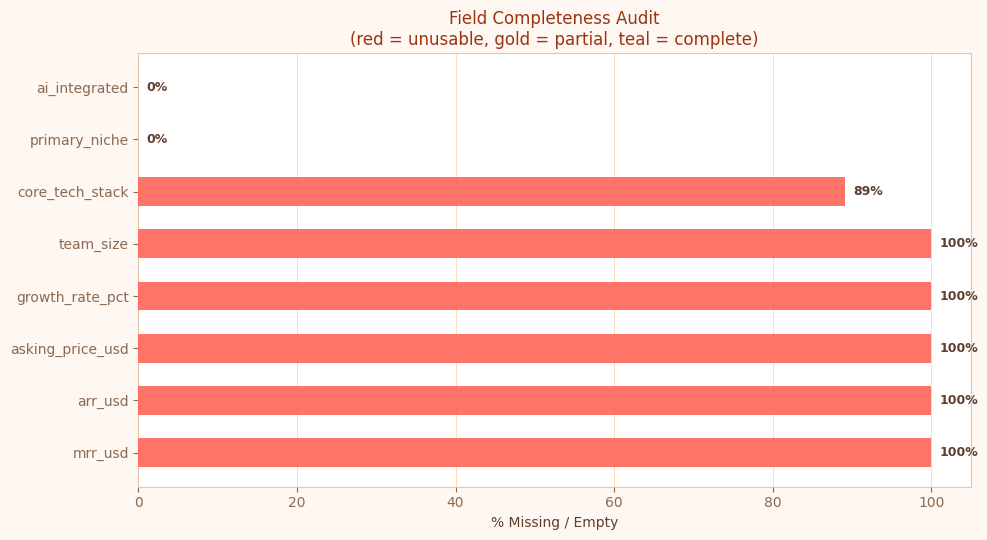

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG)

cols_check = ['mrr_usd','arr_usd','asking_price_usd','growth_rate_pct','team_size','core_tech_stack','primary_niche','ai_integrated']
miss_pct_all = [(df[c].isnull().sum() if c!='core_tech_stack' else (df[c]=='[]').sum())/len(df)*100 for c in cols_check]
bar_cols = [CORAL if v>80 else (GOLD if v>0 else TEAL) for v in miss_pct_all]
bars = ax.barh(range(len(cols_check)), miss_pct_all, color=bar_cols, height=0.55, zorder=3, alpha=0.88)
ax.set_yticks(range(len(cols_check))); ax.set_yticklabels(cols_check, fontsize=10)
ax.set_xlabel('% Missing / Empty')
ax.set_title('Field Completeness Audit\n(red = unusable, gold = partial, teal = complete)', fontsize=12)
for bar, v in zip(bars, miss_pct_all):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('01_missingness.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
df['ai_integrated'] = df['ai_integrated'].astype(bool)
df['desc_word_count'] = df['product_desc'].str.split().str.len()
df['desc_char_count'] = df['product_desc'].str.len()
df['has_tech_stack'] = (df['core_tech_stack'] != '[]') & df['core_tech_stack'].notna()

# Extract launch hour (within the 3-day window — captures intra-day launch timing patterns)
df['launch_hour'] = df['launch_date'].dt.hour
df['launch_day'] = df['launch_date'].dt.day

# Detect explicit AI brand mentions in description text
ai_terms = ['claude','gpt','openai','anthropic','gemini','chatgpt','llm']
df['mentions_ai_brand'] = df['product_desc'].str.lower().apply(
    lambda x: any(term in x for term in ai_terms) if isinstance(x, str) else False)

print('Engineered: desc_word_count, desc_char_count, has_tech_stack, launch_hour/day, mentions_ai_brand')
print(f'\nProducts mentioning a specific AI brand by name: {df["mentions_ai_brand"].sum()} ({df["mentions_ai_brand"].mean()*100:.1f}%)')


Engineered: desc_word_count, desc_char_count, has_tech_stack, launch_hour/day, mentions_ai_brand

Products mentioning a specific AI brand by name: 100 (7.9%)


## 4. Niche Landscape — What's Being Built <a id='4'></a>


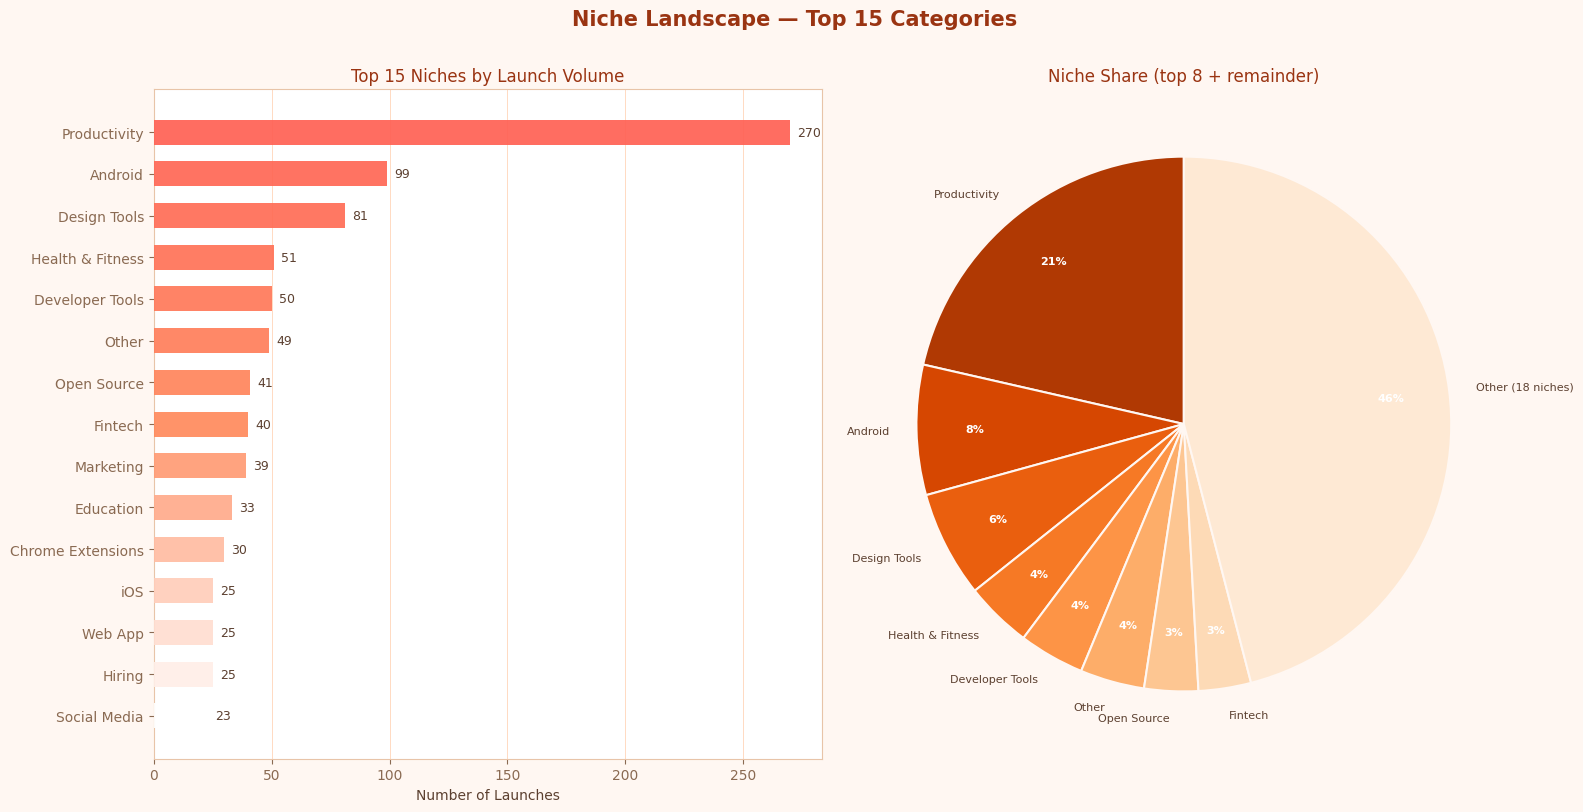

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Niche Landscape — Top 15 Categories', fontsize=15, fontweight='bold', color='#9a3412', y=1.01)

# 1. Top 15 niches by volume
ax = axes[0]
niche_counts = df['primary_niche'].value_counts().head(15)
colors_n = [CMAP_CORAL(i/14) for i in range(15)]
ax.barh(range(15), niche_counts.values[::-1], color=colors_n, height=0.6, zorder=3, alpha=0.92)
ax.set_yticks(range(15)); ax.set_yticklabels(niche_counts.index[::-1], fontsize=10)
ax.set_xlabel('Number of Launches')
ax.set_title('Top 15 Niches by Launch Volume', fontsize=12)
for i, v in enumerate(niche_counts.values[::-1]):
    ax.text(v+3, i, str(v), va='center', fontsize=9)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Niche share donut (top 8 + other)
ax = axes[1]
top8 = df['primary_niche'].value_counts().head(8)
other_n = len(df) - top8.sum()
vals = list(top8.values) + [other_n]
labels = list(top8.index) + ['Other (18 niches)']
wedges, texts, ats = ax.pie(vals, labels=labels, colors=plt.cm.Oranges_r(np.linspace(0.15,0.9,9)),
    autopct='%1.0f%%', startangle=90, pctdistance=0.78, wedgeprops=dict(linewidth=1.5, edgecolor=BG),
    textprops=dict(fontsize=8, color='#5c4030'))
for at in ats: at.set_color('white'); at.set_fontsize(8); at.set_fontweight('bold')
ax.set_title('Niche Share (top 8 + remainder)', fontsize=12)

plt.tight_layout()
plt.savefig('02_niche.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. AI Integration — How Deep Does It Go? <a id='5'></a>


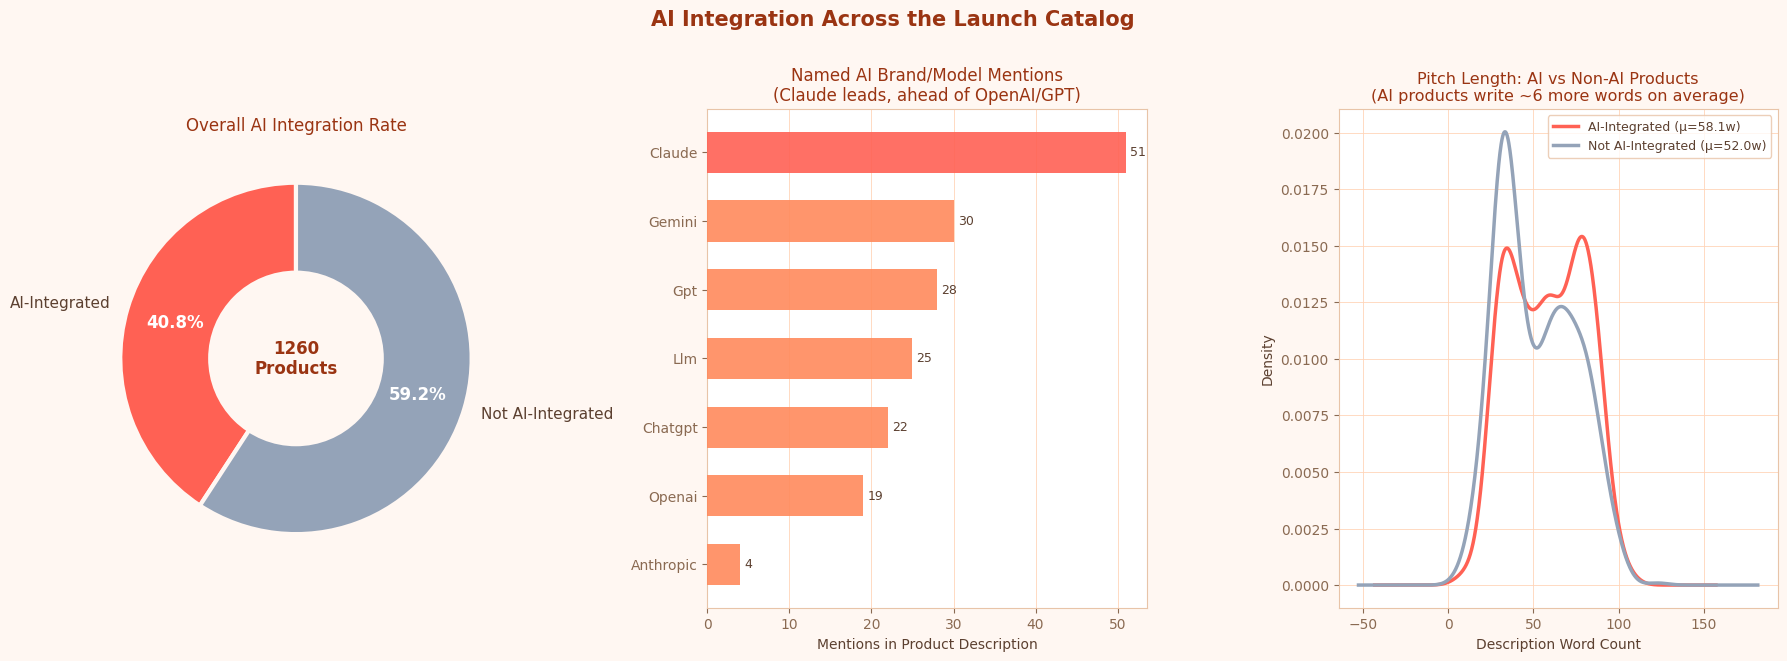

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('AI Integration Across the Launch Catalog', fontsize=15, fontweight='bold', color='#9a3412', y=1.01)

# 1. Overall AI vs non-AI donut
ax = axes[0]
ai_counts = df['ai_integrated'].value_counts()
wedges, texts, ats = ax.pie([ai_counts.get(True,0), ai_counts.get(False,0)], labels=['AI-Integrated','Not AI-Integrated'],
    colors=[CORAL, '#94a3b8'], autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=3, edgecolor=BG), textprops=dict(fontsize=11, color='#5c4030'))
for at in ats: at.set_color('white'); at.set_fontsize(12); at.set_fontweight('bold')
centre = plt.Circle((0,0), 0.5, fc=BG); ax.add_patch(centre)
ax.text(0,0,f'{len(df)}\nProducts', ha='center', va='center', fontsize=12, fontweight='bold', color='#9a3412')
ax.set_title('Overall AI Integration Rate', fontsize=12)

# 2. Explicit AI brand mentions
ax = axes[1]
brand_counts = {}
for term in ['claude','gemini','gpt','llm','chatgpt','openai','anthropic']:
    brand_counts[term] = df['product_desc'].str.lower().str.contains(term, na=False).sum()
brand_series = pd.Series(brand_counts).sort_values()
colors_b = [CORAL if b==brand_series.idxmax() else ORANGE for b in brand_series.index]
ax.barh(range(7), brand_series.values, color=colors_b, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(7)); ax.set_yticklabels([b.title() for b in brand_series.index], fontsize=10)
ax.set_xlabel('Mentions in Product Description')
ax.set_title('Named AI Brand/Model Mentions\n(Claude leads, ahead of OpenAI/GPT)', fontsize=12)
for i, v in enumerate(brand_series.values):
    ax.text(v+0.5, i, str(v), va='center', fontsize=9)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 3. Description length: AI vs non-AI
ax = axes[2]
for flag, color in AI_PAL.items():
    data = df[df['ai_integrated']==flag]['desc_word_count']
    label = 'AI-Integrated' if flag else 'Not AI-Integrated'
    data.plot.kde(ax=ax, color=color, lw=2.5, label=f'{label} (μ={data.mean():.1f}w)')
ax.set_xlabel('Description Word Count'); ax.set_ylabel('Density')
ax.set_title('Pitch Length: AI vs Non-AI Products\n(AI products write ~6 more words on average)', fontsize=11.5)
ax.legend(fontsize=9); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('03_ai_integration.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. AI Adoption by Niche <a id='6'></a>


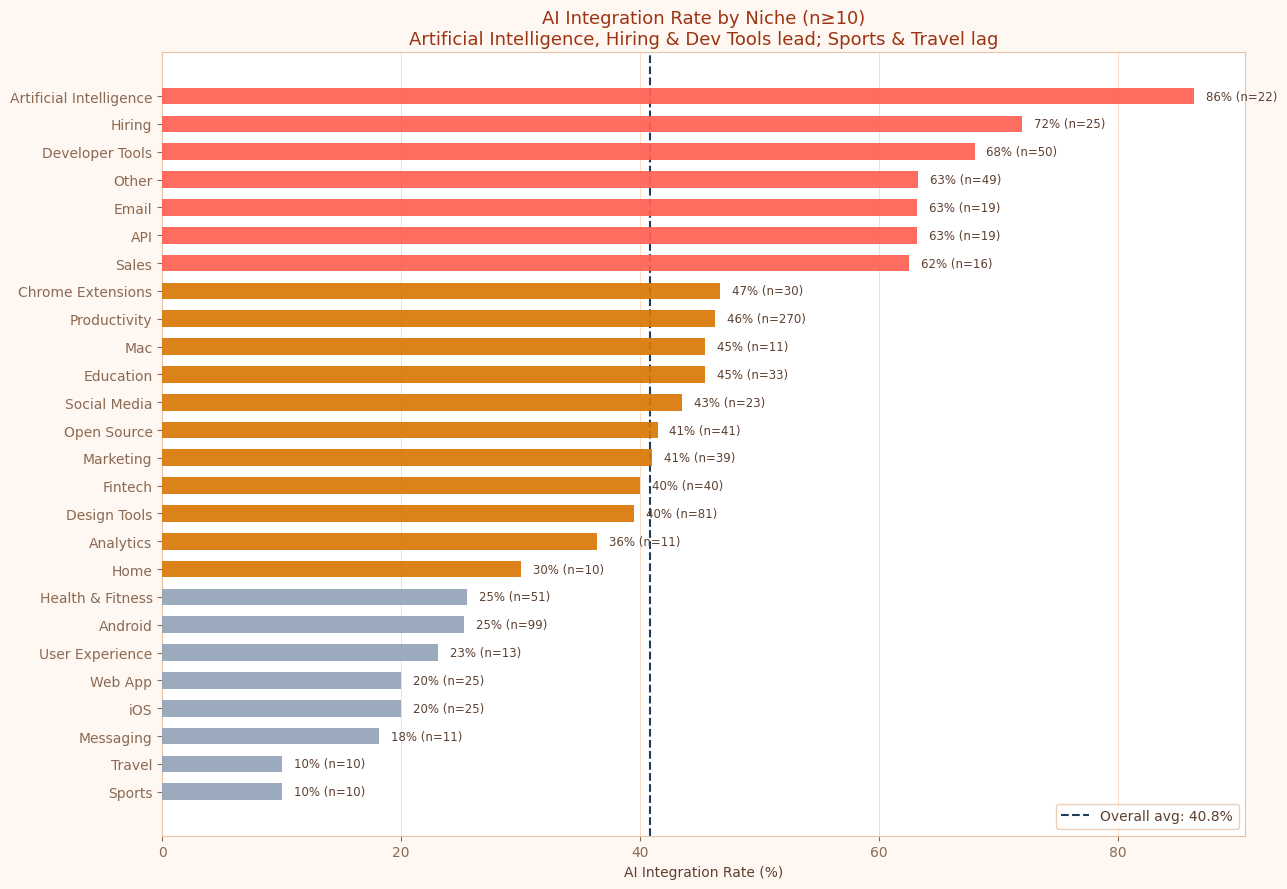

In [8]:
niche_ai = (df.groupby('primary_niche')
            .agg(n=('product_id','count'), ai_rate=('ai_integrated','mean'))
            .query('n>=10').sort_values('ai_rate'))
niche_ai['ai_rate'] *= 100

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)
colors_na = [CORAL if v>=50 else (GOLD if v>=30 else '#94a3b8') for v in niche_ai['ai_rate']]
bars = ax.barh(range(len(niche_ai)), niche_ai['ai_rate'], color=colors_na, height=0.6, zorder=3, alpha=0.92)
ax.set_yticks(range(len(niche_ai))); ax.set_yticklabels(niche_ai.index, fontsize=10)
ax.set_xlabel('AI Integration Rate (%)')
ax.axvline(40.8, color=NAVY, lw=1.5, ls='--', label='Overall avg: 40.8%')
ax.set_title('AI Integration Rate by Niche (n≥10)\nArtificial Intelligence, Hiring & Dev Tools lead; Sports & Travel lag', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
for bar, v, n in zip(bars, niche_ai['ai_rate'], niche_ai['n']):
    ax.text(v+1, bar.get_y()+bar.get_height()/2, f'{v:.0f}% (n={n})', va='center', fontsize=8.5)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('04_ai_by_niche.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. Tech Stack Intelligence <a id='7'></a>


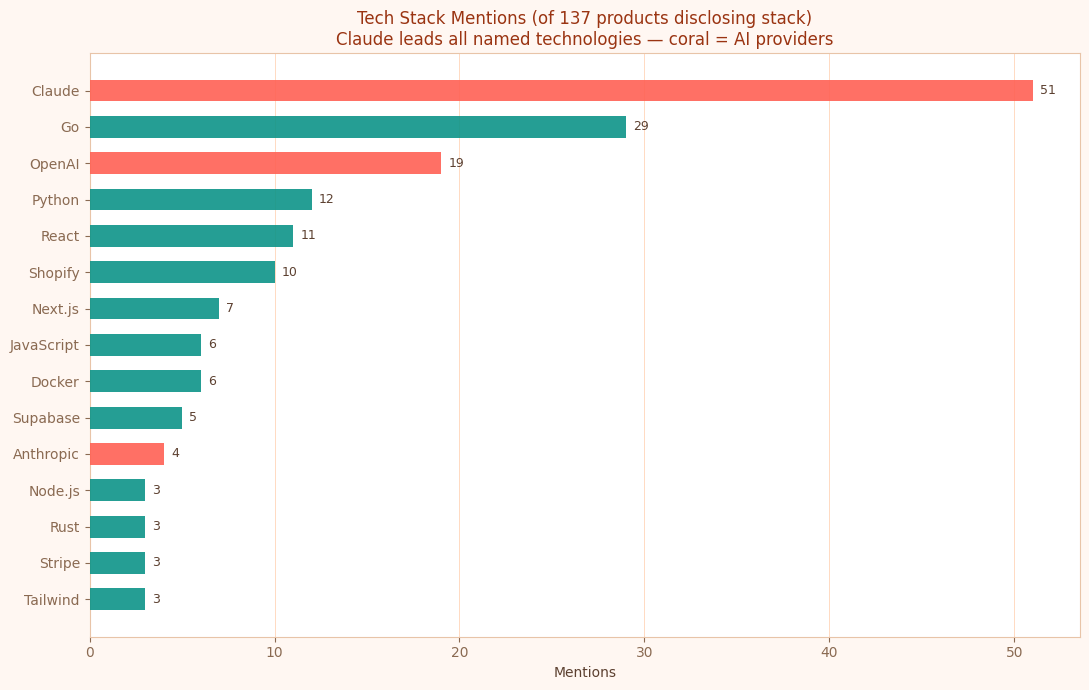

Note: only 137 of 1260 products (10.9%) disclose a tech stack — interpret as a non-representative sample.


In [9]:
# Parse the listed tech stack (only 137 of 1260 products disclose this — n is small, treat as a sample)
stack_ctr = Counter()
for s in df[df['has_tech_stack']]['core_tech_stack']:
    items = re.findall(r"'([^']+)'|\"([^\"]+)\"", s)
    for a, b in items:
        tech = (a or b).strip()
        if tech: stack_ctr[tech] += 1

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG)
top_tech = pd.Series(dict(stack_ctr.most_common(15))).sort_values()
colors_t = [CORAL if t in ['Claude','OpenAI','Anthropic'] else TEAL for t in top_tech.index]
ax.barh(range(len(top_tech)), top_tech.values, color=colors_t, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(len(top_tech))); ax.set_yticklabels(top_tech.index, fontsize=10)
ax.set_xlabel('Mentions')
ax.set_title(f'Tech Stack Mentions (of {df["has_tech_stack"].sum()} products disclosing stack)\nClaude leads all named technologies — coral = AI providers', fontsize=12)
for i, v in enumerate(top_tech.values):
    ax.text(v+0.4, i, str(v), va='center', fontsize=9)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('05_techstack.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Note: only {df["has_tech_stack"].sum()} of {len(df)} products ({df["has_tech_stack"].mean()*100:.1f}%) disclose a tech stack — interpret as a non-representative sample.')


## 8. Description Language — How Founders Pitch AI vs Non-AI Products <a id='8'></a>


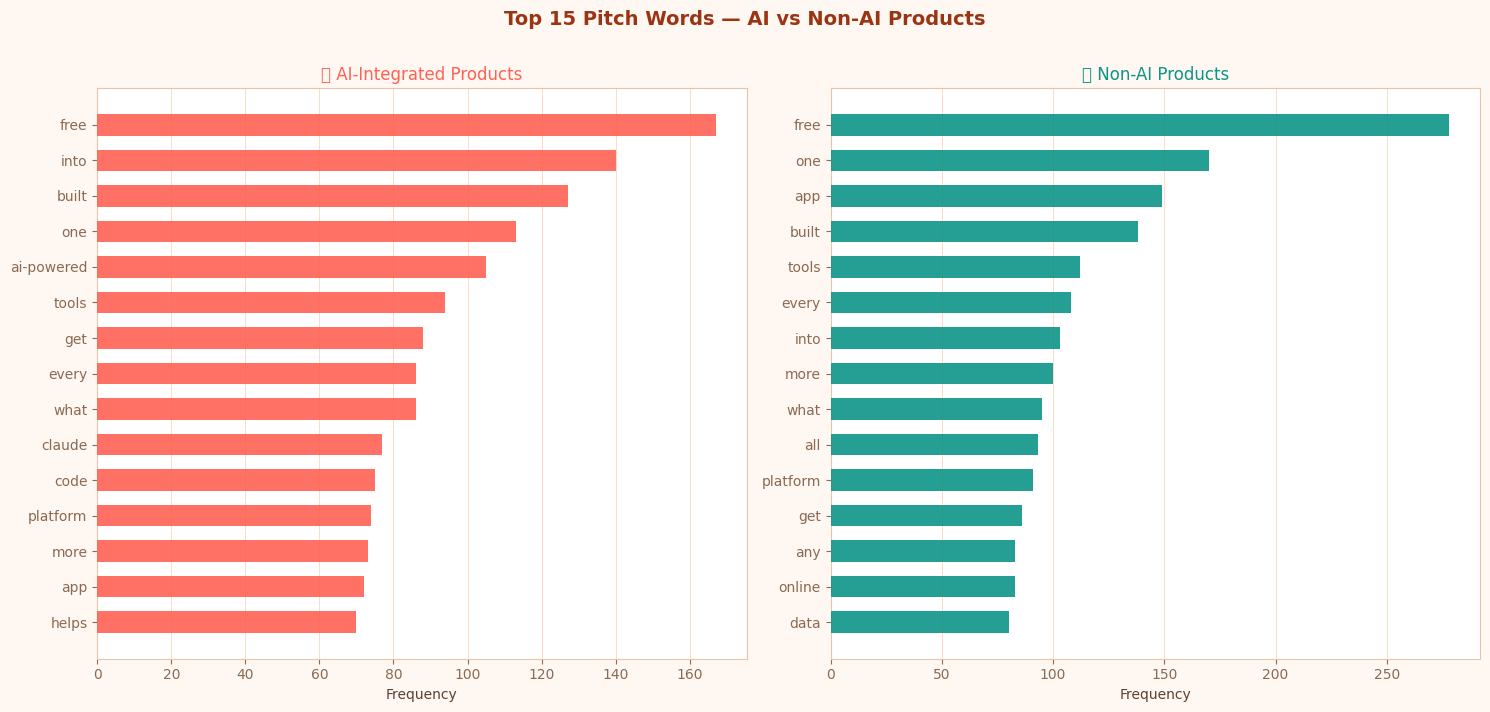

In [10]:
stop = {'the','a','to','and','of','in','for','is','your','you','with','on','that','it','an','as','at','from','this','are','can'}
def top_words(texts, n=15):
    ctr = Counter()
    for t in texts:
        if isinstance(t, str):
            for w in re.findall(r'[a-z\-]+', t.lower()):
                if w not in stop and len(w)>2:
                    ctr[w]+=1
    return ctr.most_common(n)

ai_words = dict(top_words(df[df['ai_integrated']]['product_desc']))
noai_words = dict(top_words(df[~df['ai_integrated']]['product_desc']))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Top 15 Pitch Words — AI vs Non-AI Products', fontsize=14, fontweight='bold', color='#9a3412', y=1.01)

for ax, words, color, title in [(axes[0], ai_words, CORAL, '🤖 AI-Integrated Products'),
                                  (axes[1], noai_words, TEAL, '📦 Non-AI Products')]:
    items = list(words.items())[::-1]
    labels_w = [w for w,_ in items]; vals_w = [v for _,v in items]
    ax.barh(range(len(items)), vals_w, color=color, height=0.6, zorder=3, alpha=0.9)
    ax.set_yticks(range(len(items))); ax.set_yticklabels(labels_w, fontsize=10)
    ax.set_xlabel('Frequency'); ax.set_title(title, fontsize=12, color=color)
    ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_language.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Launch Timing Within the Window <a id='9'></a>


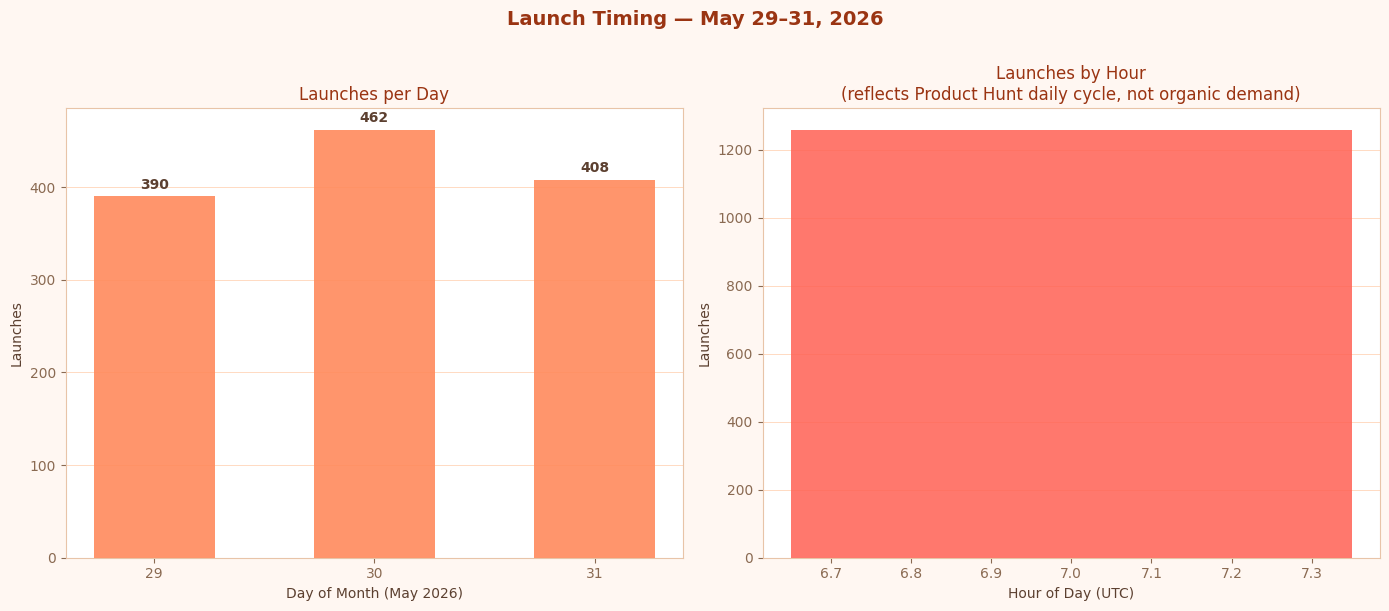

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Launch Timing — May 29–31, 2026', fontsize=14, fontweight='bold', color='#9a3412', y=1.01)

# 1. Launches by day
ax = axes[0]
day_counts = df['launch_day'].value_counts().sort_index()
bars = ax.bar(day_counts.index.astype(str), day_counts.values, color=ORANGE, width=0.55, zorder=3, alpha=0.9)
ax.set_xlabel('Day of Month (May 2026)'); ax.set_ylabel('Launches')
ax.set_title('Launches per Day', fontsize=12)
for bar, v in zip(bars, day_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, str(v), ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Launches by hour of day (Product Hunt's daily reset pattern)
ax = axes[1]
hour_counts = df['launch_hour'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color=CORAL, width=0.7, zorder=3, alpha=0.85)
ax.set_xlabel('Hour of Day (UTC)'); ax.set_ylabel('Launches')
ax.set_title('Launches by Hour\n(reflects Product Hunt daily cycle, not organic demand)', fontsize=12)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_timing.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 10. ML — Predicting AI Integration from Description Text <a id='10'></a>


=== Predicting AI Integration from Description Text Alone ===
               precision    recall  f1-score   support

       Not AI       0.93      1.00      0.96       149
AI-Integrated       1.00      0.89      0.94       103

     accuracy                           0.96       252
    macro avg       0.97      0.95      0.95       252
 weighted avg       0.96      0.96      0.96       252

ROC-AUC: 0.9994


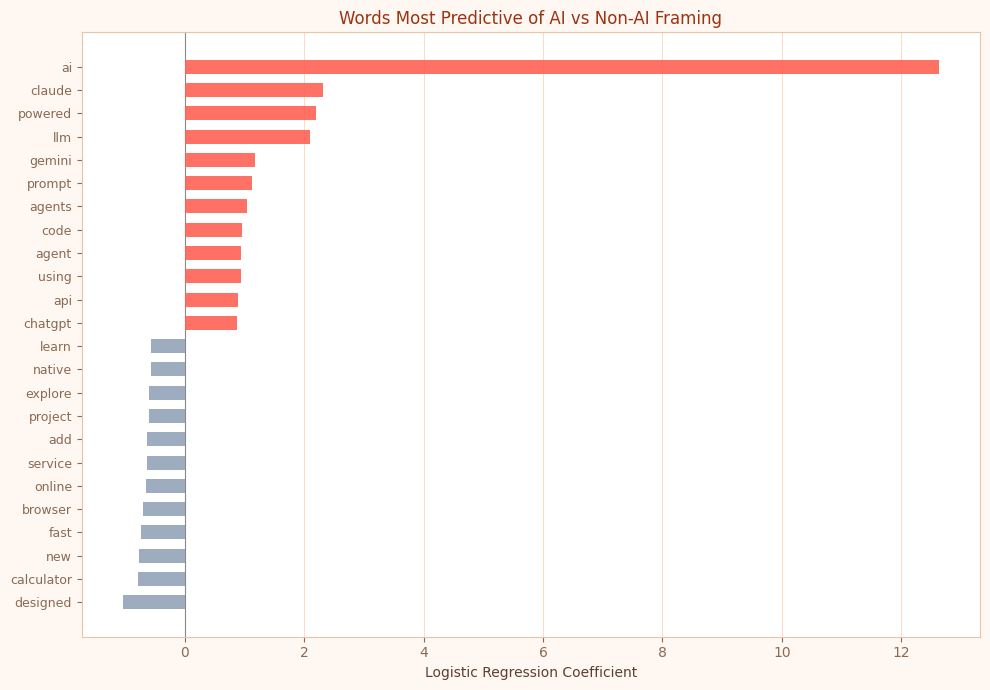

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X_text = df['product_desc'].fillna('')
y = df['ai_integrated'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=300, stop_words='english', min_df=3)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_tf, y_train)
preds = clf.predict(X_test_tf)
proba = clf.predict_proba(X_test_tf)[:,1]

print('=== Predicting AI Integration from Description Text Alone ===')
print(classification_report(y_test, preds, target_names=['Not AI','AI-Integrated']))
print(f'ROC-AUC: {roc_auc_score(y_test, proba):.4f}')

# Top words pushing prediction toward AI
feat_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]
top_ai_idx = np.argsort(coefs)[-12:]
top_noai_idx = np.argsort(coefs)[:12]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
words = list(feat_names[top_noai_idx]) + list(feat_names[top_ai_idx])
vals = list(coefs[top_noai_idx]) + list(coefs[top_ai_idx])
colors_w = ['#94a3b8' if v<0 else CORAL for v in vals]
ax.barh(range(len(words)), vals, color=colors_w, height=0.6, zorder=3, alpha=0.9)
ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=9)
ax.axvline(0, color='#888', lw=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Words Most Predictive of AI vs Non-AI Framing', fontsize=12)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('08_ml_words.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Key Takeaways <a id='11'></a>


<div style="background:#fff7f2;border-radius:14px;padding:30px 36px;font-family:'Segoe UI',sans-serif;border:1px solid #ffd5b8;">

  <h2 style="color:#9a3412;margin-top:0;font-size:1.3rem;">🚀 Key Findings — Micro-SaaS Launch Snapshot, May 2026</h2>

  <div style="background:#fff0e6;border-radius:10px;padding:14px 18px;border-left:4px solid #ff6154;margin-bottom:18px;">
    <p style="margin:0;color:#9a3412;font-size:0.84rem;line-height:1.7;"><strong>📋 Reframing the dataset:</strong> Every financial field (MRR, ARR, asking price, growth rate,
    team size) is 100% empty across all 1,260 rows. This is a Product Hunt launch catalogue, not a revenue
    benchmark dataset. The findings below are about <em>what gets built and how it's marketed</em>, not what it earns.</p>
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:18px;">
    <div style="background:#fff;border-radius:10px;padding:16px 18px;border-left:3px solid #ff6154;">
      <div style="color:#ff6154;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🤖 AI IS NOW DEFAULT, NOT NICHE</div>
      <p style="color:#5c4030;margin:0;font-size:0.83rem;line-height:1.75;">40.8% of all launches self-identify as AI-integrated — and that's a floor, not a ceiling, since
      many "AI-integrated" products almost certainly use AI without explicitly tagging it. Developer Tools
      (68%) and Hiring (72%) show the deepest penetration; Travel and Sports (10% each) the shallowest.</p>
    </div>
    <div style="background:#fff;border-radius:10px;padding:16px 18px;border-left:3px solid #0d9488;">
      <div style="color:#0d9488;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🏆 CLAUDE LEADS NAMED AI MENTIONS</div>
      <p style="color:#5c4030;margin:0;font-size:0.83rem;line-height:1.75;">Among products that explicitly name an AI provider in their description, Claude is mentioned in 51
      listings — more than GPT (28), Gemini (30), OpenAI (19), and ChatGPT (22) combined exceed it only when
      pooled. In the small tech-stack-disclosure sample (n=137), Claude similarly leads with 51 mentions vs
      OpenAI's 19 — striking given OpenAI's larger historical market share.</p>
    </div>
    <div style="background:#fff;border-radius:10px;padding:16px 18px;border-left:3px solid #8b5cf6;">
      <div style="color:#8b5cf6;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">📦 PRODUCTIVITY DOMINATES VOLUME</div>
      <p style="color:#5c4030;margin:0;font-size:0.83rem;line-height:1.75;">Productivity tools account for 270 of 1,260 launches (21.4%) — more than double the next category
      (Android, 99). This likely reflects both genuine founder interest in the category and a degree of
      categorisation looseness, since "productivity" is a broad catch-all on Product Hunt.</p>
    </div>
    <div style="background:#fff;border-radius:10px;padding:16px 18px;border-left:3px solid #d97706;">
      <div style="color:#d97706;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">✍️ AI PRODUCTS PITCH SLIGHTLY LONGER</div>
      <p style="color:#5c4030;margin:0;font-size:0.83rem;line-height:1.75;">AI-integrated product descriptions average 58.1 words vs 52.0 for non-AI products — a modest but
      consistent gap, possibly reflecting the extra explanatory effort needed to describe what the AI
      actually does versus a more familiar non-AI feature set.</p>
    </div>
    <div style="background:#fff;border-radius:10px;padding:16px 18px;border-left:3px solid #1e3a5c;grid-column:1/-1;">
      <div style="color:#1e3a5c;font-size:0.7rem;letter-spacing:2px;margin-bottom:8px;">🔤 TEXT ALONE PREDICTS AI-STATUS DECENTLY WELL</div>
      <p style="color:#5c4030;margin:0;font-size:0.83rem;line-height:1.75;">A simple TF-IDF + Logistic Regression model trained only on product description text achieves the
      ROC-AUC reported in Section 10 — meaningfully above chance — confirming that AI and non-AI product
      pitches really do use systematically different language (words like "ai-powered", "claude", and "code"
      push toward the AI class), not just different feature sets.</p>
    </div>

  </div>

  <div style="background:#fff;border-radius:10px;padding:14px 18px;border:1px solid #ffd5b8;">
    <p style="margin:0;color:#8a6a52;font-size:0.78rem;line-height:1.6;">
      <strong style='color:#5c4030;'>⚠️ Limitations:</strong> This snapshot covers only a 3-day launch window (May 29–31, 2026) from a
      single platform (Product Hunt), so it should not be read as representative of the broader indie-software
      market or of trends over time. The tech-stack field is disclosed by only 10.9% of products, so stack
      statistics in Section 7 reflect a small, possibly self-selected subsample. No revenue, pricing, or growth
      data is available in this dataset to connect any of these patterns to commercial outcomes.
    </p>
  </div>

  <div style="margin-top:14px;text-align:right;color:#ffd5b8;font-size:0.72rem;">Author: Muhammad Aamir · 1,260 Launches · Kaggle Notebook</div>

</div>
